In [1]:
# Check if using GPU
import tensorflow as tf
if tf.test.gpu_device_name() == '/device:GPU:0':
  print("GPU is active")
else:
  print("GPU is not active")

GPU is active


In [2]:
#@title Default title text
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!pip install whitebox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 6.9 MB/s eta 0:00:00


In [4]:
!pip install whitebox-workflows

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 51.6 MB/s eta 0:00:00


In [5]:
!pip install geemap

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)


In [6]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 43.1 MB/s eta 0:00:00


In [7]:
!pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00


In [8]:
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00


In [9]:
import whitebox
import whitebox_workflows as wbw
import geemap
import rioxarray as rxr
import rasterio
import earthpy as et
import earthpy.plot as ep
import matplotlib.pyplot as plt
import geopandas as gpd
from rasterio.plot import plotting_extent

In [10]:
wbt = whitebox.WhiteboxTools()

Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.10/dist-packages/whitebox


In [11]:
# Assign CRS to the DSM
geemap.add_crs("/content/drive/MyDrive/Doktora/nrm_vgt.tif",
               epsg=5258) # This CRS is based on one of the shapefiles within the downloaded data

# Read the raster using rioxarray
dsm = rxr.open_rasterio("/content/drive/MyDrive/Doktora/nrm_vgt.tif",
                            masked=True)

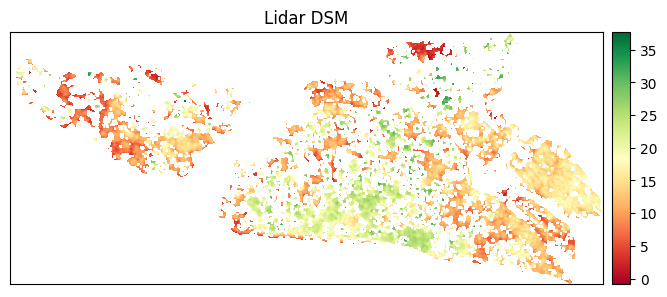

In [12]:
# View the raster
ep.plot_bands(
    arr=dsm,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar DSM"
)

plt.show();

In [31]:
# Fill the DSM missing data
wbt.fill_missing_data(
    i="/content/drive/MyDrive/Doktora/nrm_vgt.tif",
    output="/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif",
    filter=10,
    weight=2,
    no_edges=False,
)

./whitebox_tools --run="FillMissingData" --input='/content/drive/MyDrive/Doktora/nrm_vgt.tif' --output='/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif' --filter=10 --weight=2 -v --compress_rasters=False

******************************
* Welcome to FillMissingData *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Interpolating data holes...
Interpolating data holes: 0%
Interpolating data holes: 1%
Interpolating data holes: 2%
Interpolating data holes: 3%
Interpolating data holes: 4%
Interpolating data holes: 5%
Interpolating data holes: 6%
Interpolating data holes: 7%
Interpolating data holes: 8%
Interpolating data holes: 9%
Interpolating data holes: 10%
Interpolating data holes: 11%
Interpolating data holes: 12%
Interpolating data holes: 13%
Interpolating data holes: 14%
Interpolating data holes: 15%
Interpolating data holes: 16%
Interpolating data holes: 17%
Interpolating data holes: 18%
Interpolating data holes: 19%
Inte

0

In [32]:
# Assign CRS to the DSM
geemap.add_crs("/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif",
               epsg=5258) # This CRS is based on one of the shapefiles within the downloaded data

# Read the raster using rioxarray
dsm_filled = rxr.open_rasterio("/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif",
                            masked=True)


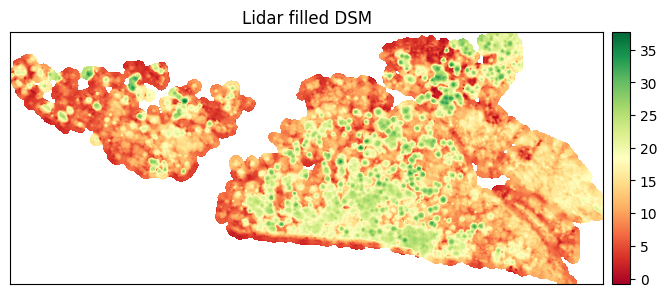

In [33]:
# View the raster
ep.plot_bands(
    arr=dsm_filled,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Lidar filled DSM"
)

plt.show();

In [34]:
# Assign CRS to both CHMs
geemap.add_crs("/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif",
               epsg=5258) # This CRS is based on one of the shapefiles within the downloaded data

geemap.add_crs("/content/drive/MyDrive/Doktora/chm_tin.tif",
               epsg=5258) # This CRS is based on one of the shapefiles within the downloaded data

In [37]:
# Read both CHM rasters using rioxarray
chm_idw = rxr.open_rasterio("/content/drive/MyDrive/Doktora/nrm_vgt_filled.tif",
                            masked=True)

chm_tin = rxr.open_rasterio("/content/drive/MyDrive/Doktora/chm_tin.tif",
                            masked=True)

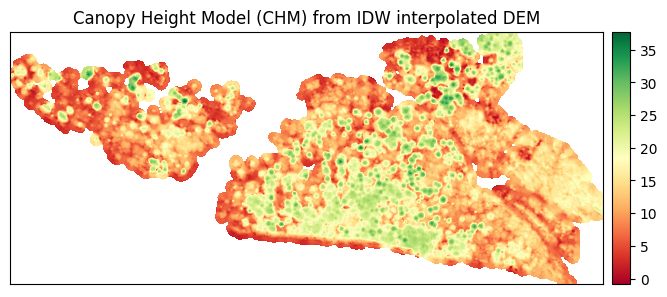

In [38]:
# Plot the CHM from IDW Interpolated DEM
ep.plot_bands(
    arr=chm_idw,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Canopy Height Model (CHM) from IDW interpolated DEM"
)

plt.show();

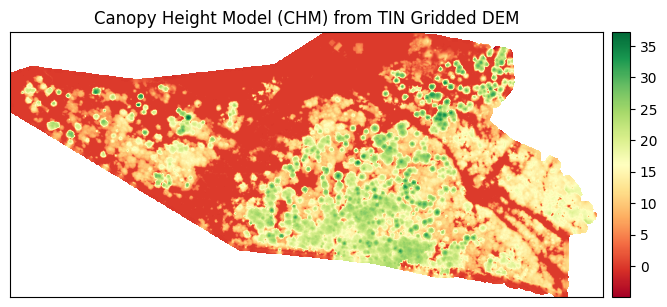

In [ ]:
# Plot the CHM from TIN Gridded DEM
ep.plot_bands(
    arr=chm_tin,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Canopy Height Model (CHM) from TIN Gridded DEM"
)

plt.show();

In [ ]:
# Normalize the Lidar data
# A normalized point cloud is one for which the point z-values represent height above the ground surface rather than
# raw elevation values. Thus, a point that falls on the ground surface will have a z-value of zero and vegetation points,
# and points associated with other off-terrain objects, have positive, non-zero z-values.
# See: https://www.whiteboxgeo.com/manual/wbt_book/available_tools/lidar_tools.html#normalizelidar

wbt.normalize_lidar(
    i="/content/drive/MyDrive/Doktora/TBC-Class-Building-Ground-HVegetation.las",
    output="/content/drive/MyDrive/Doktora/data_normalized.las",
    dtm="/content/drive/MyDrive/Doktora/idw_dtm_filled.tif", # Personal choice is that the IDW filled DEM is better...it had zero holes
)


./whitebox_tools --run="NormalizeLidar" --input='/content/drive/MyDrive/Doktora/TBC-Class-Building-Ground-HVegetation.las' --output='/content/drive/MyDrive/Doktora/data_normalized.las' --dtm='/content/drive/MyDrive/Doktora/idw_dtm_filled.tif' -v --compress_rasters=False

*****************************
* Welcome to NormalizeLidar *
* Powered by WhiteboxTools  *
* www.whiteboxgeo.com       *
*****************************
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Progress: 39%
Progress: 40%
Progress: 41%


0

In [39]:
# Load the individually detected trees
trees = gpd.read_file("/content/drive/MyDrive/Doktora/ITD_whitebox_2.shp")

# Assign a CRS to this shapefile
trees.crs = "epsg:5258"

In [40]:
# Save this shapefile for further use
trees.to_file("/content/drive/MyDrive/Doktora/ITD_whitebox_2_5258.shp")

In [ ]:
# Get dimensions of CHM. Useful in getting the extent
# chm_idw

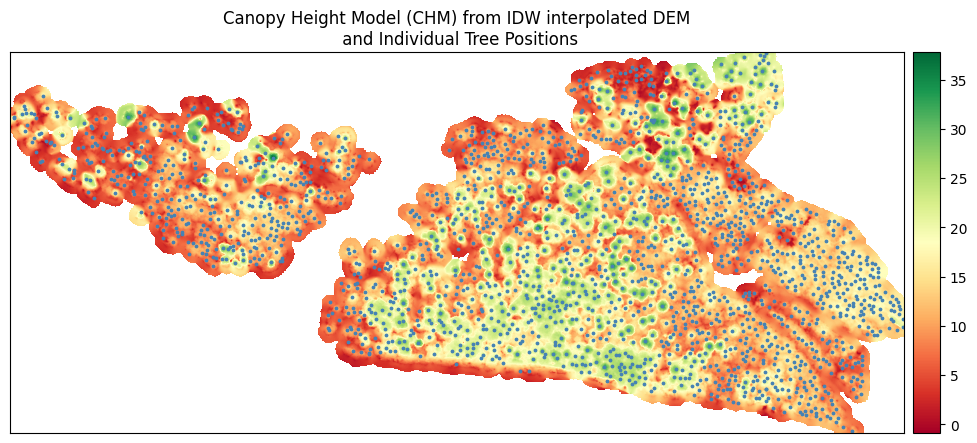

In [41]:
# Plot the trees shapefile overlying the CHM from IDW DEM

fig, ax = plt.subplots(figsize=(12, 8))

# Get plotting extent of CHM
chm_extent = plotting_extent(chm_idw[0],
                             chm_idw.rio.transform())

# Plot the CHM from IDW Interpolated DEM
ep.plot_bands(
    arr=chm_idw,
    cmap="RdYlGn",
    figsize=(8, 8),
    title="Canopy Height Model (CHM) from IDW interpolated DEM\n and Individual Tree Positions",
    extent=chm_extent,
    ax=ax
)

trees.plot(color="steelblue",
                    ax=ax,
                    markersize=3)

plt.show();